# Analisa Data Menggunakan Pohon Keputusan

## Pengertian Pohon Keputusan (Decision Tree)

Pohon Keputusan (*Decision Tree*) adalah metode klasifikasi yang membentuk struktur menyerupai pohon untuk menghasilkan keputusan berdasarkan atribut tertentu.

Struktur pada Decision Tree terdiri dari:

1. **Root Node**

   Node utama yang menjadi awal percabangan.

2. **Branch**

   Cabang yang menunjukkan hasil dari suatu kondisi.

3. **Leaf Node**

   Node akhir yang menunjukkan hasil klasifikasi.

Metode ini bekerja dengan cara memilih atribut terbaik sebagai percabangan utama, kemudian data dibagi menjadi beberapa kelompok hingga menghasilkan keputusan akhir.

Kelebihan Decision Tree:

* Mudah dipahami
* Proses klasifikasi cepat
* Hasil berupa aturan yang jelas
* Cocok untuk data kategorikal

Namun metode ini juga memiliki kekurangan, seperti kemungkinan terjadinya *overfitting* apabila pohon terlalu kompleks.

---

## Konsep Dasar Decision Tree

Konsep dasar Pohon Keputusan adalah membagi data menjadi kelompok-kelompok yang memiliki karakteristik serupa. Pemilihan atribut dilakukan berdasarkan nilai terbaik yang mampu memisahkan data dengan paling baik.

Pada penelitian ini digunakan ukuran **Gain Ratio** untuk menentukan atribut terbaik.

Semakin tinggi nilai Gain Ratio suatu atribut, maka atribut tersebut dianggap semakin baik untuk dijadikan percabangan pada pohon keputusan.

---

## Entropy

Entropy digunakan untuk mengukur tingkat ketidakpastian atau ketidakteraturan data.

Apabila seluruh data berada pada kelas yang sama maka nilai entropy akan semakin kecil. Sebaliknya, jika data bercampur antara beberapa kelas maka nilai entropy akan semakin besar.

Rumus entropy:

$$
Entropy(S) = -\sum p_i \log_2 p_i
$$

Keterangan:

* (p_i) = proporsi data pada kelas ke-i
* (S) = himpunan data

---

## Information Gain

Information Gain digunakan untuk mengetahui seberapa baik suatu atribut dalam memisahkan data.

Nilai gain diperoleh dari pengurangan entropy awal dengan entropy setelah data dibagi berdasarkan atribut tertentu.

Rumus Information Gain:

$$
Gain(S,A) = Entropy(S) - \sum \frac{|S_i|}{|S|}Entropy(S_i)
$$

Keterangan:

* (S) = seluruh data
* (A) = atribut
* (S_i) = subset data hasil pembagian atribut

Semakin besar nilai gain maka semakin baik atribut tersebut dalam melakukan pemisahan data.

---

## Split Info

Split Info digunakan untuk mengukur besarnya informasi yang dihasilkan dari proses pembagian data.

Rumus Split Info:

$$
SplitInfo(S,A) = -\sum \frac{|S_i|}{|S|}\log_2\frac{|S_i|}{|S|}
$$

Nilai ini digunakan sebagai pembanding agar atribut dengan jumlah kategori terlalu banyak tidak selalu dipilih.

---

## Gain Ratio

Gain Ratio merupakan pengembangan dari Information Gain yang digunakan pada algoritma C4.5.

Metode ini bertujuan untuk memperbaiki kelemahan Information Gain yang cenderung memilih atribut dengan jumlah kategori banyak.

Rumus Gain Ratio:

$$
GainRatio(S,A) = \frac{Gain(S,A)}{SplitInfo(S,A)}
$$

Atribut dengan nilai Gain Ratio terbesar akan dipilih sebagai node atau percabangan pada Decision Tree.

---

## Dataset yang Digunakan

Dataset yang digunakan dalam proyek ini adalah *Car Evaluation Dataset* https://www.kaggle.com/datasets/elikplim/car-evaluation-data-set.

Dataset ini berisi data evaluasi kendaraan berdasarkan beberapa atribut kategorikal.

Atribut yang digunakan antara lain:

| Atribut  | Keterangan           |
| -------- | -------------------- |
| buying   | Harga beli kendaraan |
| maint    | Biaya perawatan      |
| lug_boot | Ukuran bagasi        |
| safety   | Tingkat keamanan     |
| class    | Kategori kendaraan   |

Seluruh atribut pada dataset bersifat kategorikal sehingga cocok digunakan untuk metode Decision Tree.

---

## Panjang Lintasan (Path Length)

Panjang lintasan (*path length*) adalah jumlah langkah atau percabangan yang dilewati dari root node hingga mencapai leaf node pada pohon keputusan.

Setiap lintasan menunjukkan proses pengambilan keputusan yang dilakukan model untuk menentukan hasil klasifikasi.

Pada dataset yang digunakan dalam penelitian ini, atribut yang digunakan antara lain:

* buyingprice
* maintenance coast
* lug_boot
* safety
* decision

Contoh lintasan pada Decision Tree:

```text
safety → buyingprice → maintenance coast → lug_boot → decision
```

Panjang lintasan dapat berbeda-beda tergantung hasil pembentukan pohon keputusan. Semakin banyak percabangan yang dilalui, maka proses pengambilan keputusan menjadi semakin panjang.

---


## Implementasi Menggunakan KNIME

Proses analisis dilakukan menggunakan aplikasi KNIME dengan beberapa node utama.

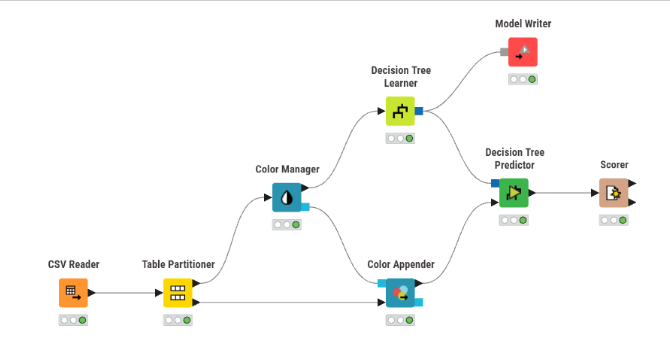

### 1. Excel Reader

Node ini digunakan untuk membaca dataset dari file Excel.

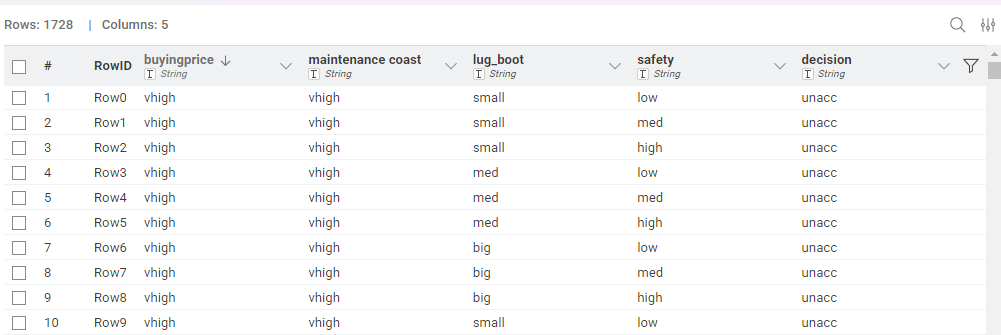

### 2. Table Partitioner

Digunakan untuk membagi data menjadi data training dan data testing.

Pembagian data dilakukan dengan perbandingan:

* 70% data training
* 30% data testing

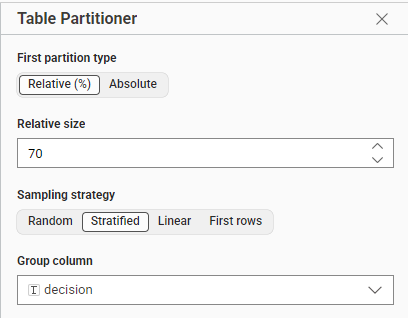



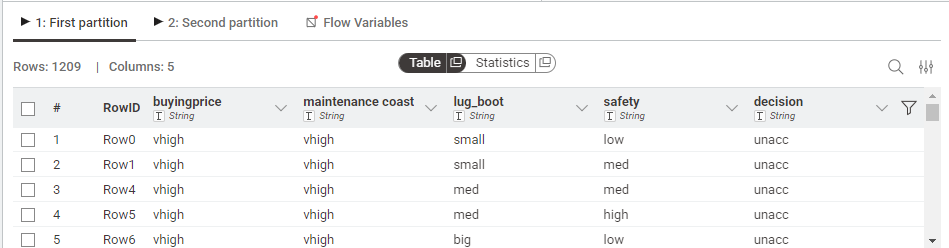



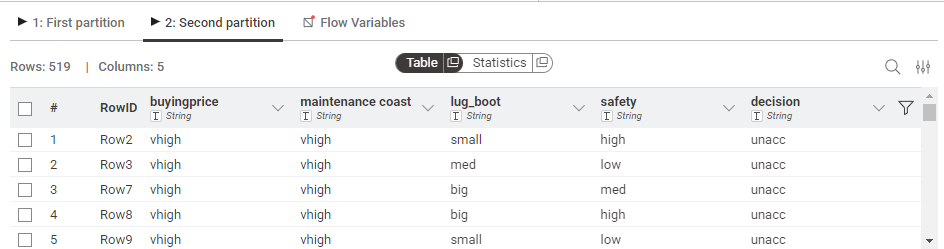


### 3. Color Manager

Digunakan untuk memberikan warna pada setiap kelas data agar lebih mudah divisualisasikan.

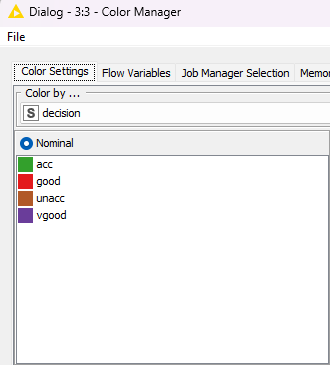



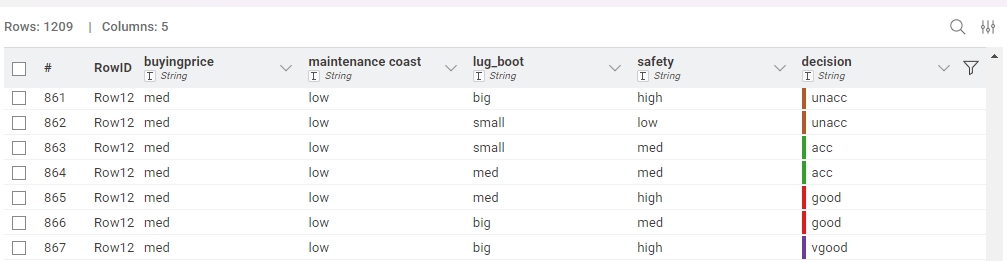



### 4. Color Appender

Digunakan untuk menerapkan atau menetapkan model warna (color model) yang sudah ada pada suatu tabel data.

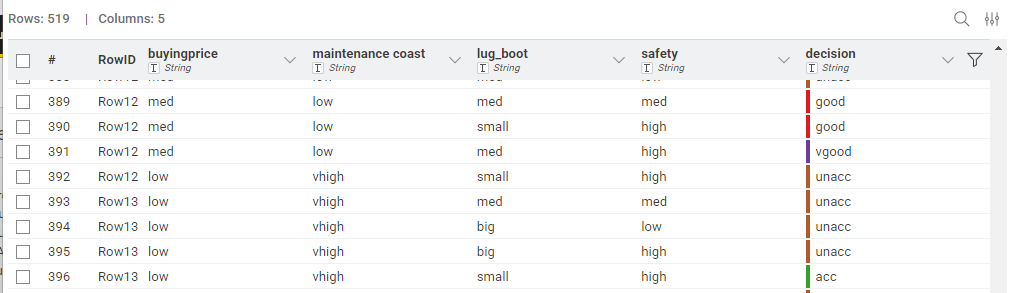

### 5. Decision Tree Learner

Node utama untuk membangun model Pohon Keputusan.

Pengaturan yang digunakan:

* Quality Measure : Gain Ratio
* Minimum records per node : 2
* Pruning method : No pruning

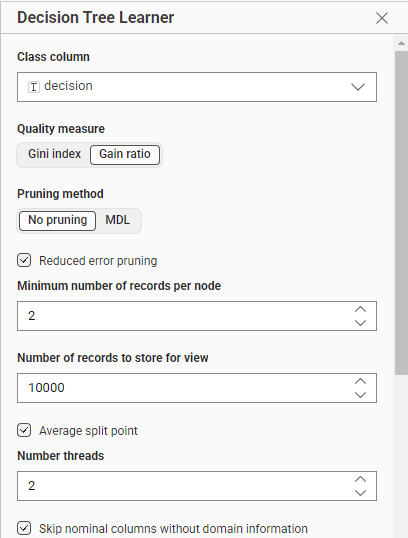



### 6. Decision Tree Predictor

Node Decision Tree Predictor digunakan untuk melakukan proses prediksi terhadap data testing menggunakan model pohon keputusan yang sebelumnya telah dibuat pada node Decision Tree Learner.

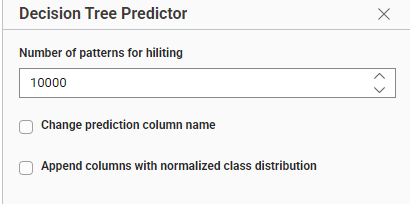



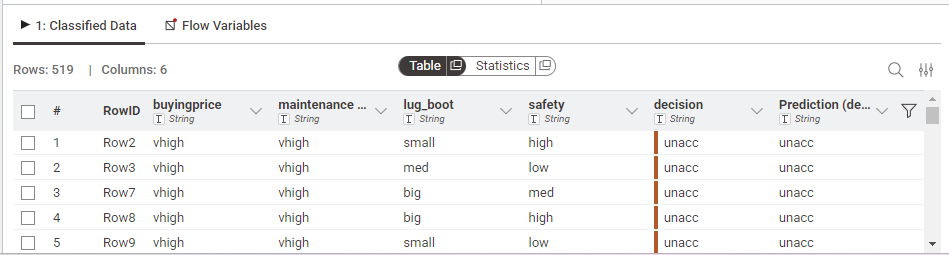



### 7. Scorer

Digunakan untuk mengevaluasi hasil prediksi dengan membandingkan data asli dan hasil prediksi.

Output dari node ini berupa:

* Confusion Matrix
* Accuracy
* Precision
* Recall

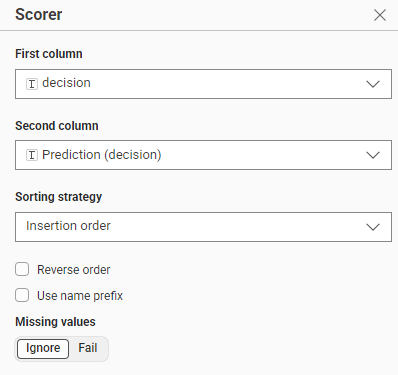



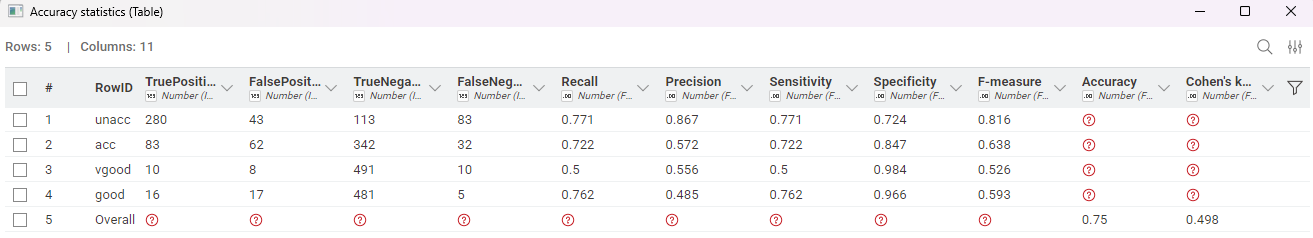

---



### 8. Model Writer

Node Model Writer digunakan untuk menyimpan model hasil pelatihan (training model) ke dalam file agar dapat digunakan kembali tanpa perlu melakukan proses pelatihan ulang.

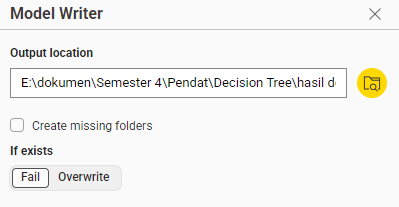

## Hasil Decision Tree

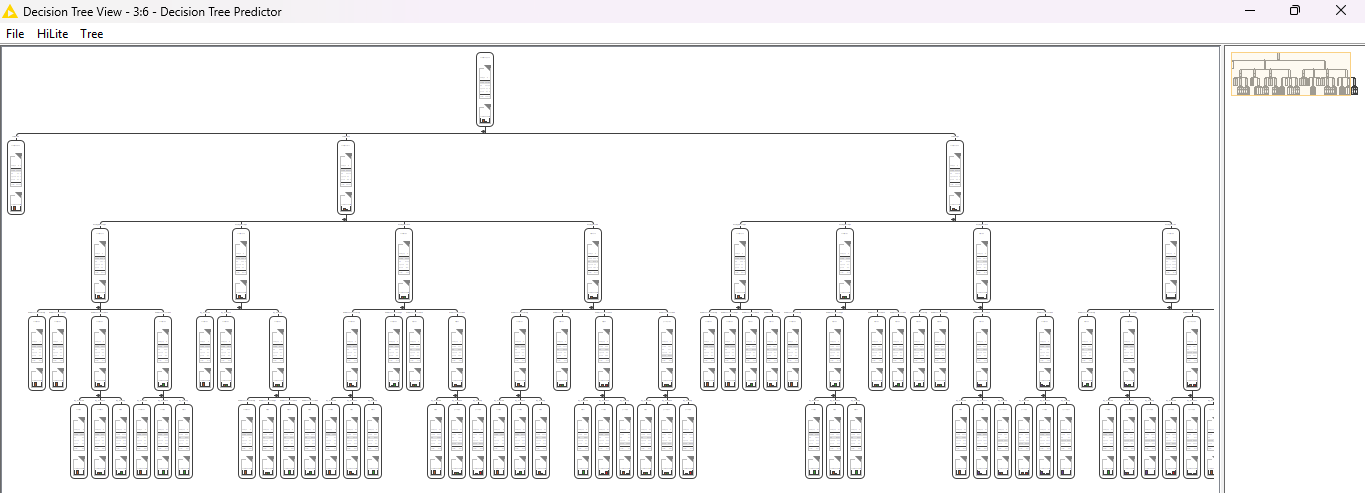

# Hasil Pengujian

Berdasarkan hasil pengujian menggunakan node Scorer, diperoleh confusion matrix yang menunjukkan jumlah data yang berhasil diprediksi dengan benar maupun salah.

Hasil evaluasi menunjukkan bahwa model Decision Tree mampu melakukan klasifikasi data kendaraan dengan tingkat akurasi yang cukup baik.

Data testing yang digunakan berasal dari 30% total dataset sehingga proses evaluasi dilakukan pada data yang belum pernah dipelajari sebelumnya.

---

# Perhitungan Accuracy

Accuracy digunakan untuk mengetahui tingkat ketepatan model dalam melakukan klasifikasi data.

Perhitungan accuracy dilakukan berdasarkan jumlah data yang berhasil diprediksi dengan benar dibandingkan dengan seluruh data testing.

Rumus accuracy:

$$
Accuracy = \frac{Jumlah\ Prediksi\ Benar}{Total\ Data} \times 100%
$$

Berdasarkan hasil confusion matrix diperoleh:

* Prediksi benar:

  * unacc = 280
  * acc = 83
  * vgood = 10
  * good = 16

Total prediksi benar:

$$
280 + 83 + 10 + 16 = 389
$$

Total data testing:

$$
519
$$

Maka perhitungan accuracy:

$$
Accuracy = \frac{389}{519} \times 100%
$$

$$
Accuracy = 74.95%
$$

Berdasarkan hasil tersebut dapat diketahui bahwa model Decision Tree mampu melakukan klasifikasi data dengan tingkat ketepatan sekitar 74.95%.

---

## Kesimpulan

Berdasarkan hasil analisis menggunakan metode Decision Tree pada Car Evaluation Dataset, atribut buyingprice, maintenance coast, lug_boot, dan safety berhasil digunakan untuk menentukan hasil klasifikasi pada atribut decision.

Model dibangun menggunakan metode Gain Ratio pada KNIME Analytics Platform dan menghasilkan nilai accuracy sebesar 74.95%. Hasil tersebut menunjukkan bahwa metode Decision Tree cukup baik digunakan untuk proses klasifikasi data kategorikal.
